## IMPORTS

In [13]:
!pip install torch torchvision

import torch
import torch.nn as nn
import torchvision
import torchvision.utils as vutils
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

## MOUNT DRIVE

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## DATA PATH

In [16]:
DATA_PATH = "/content/drive/MyDrive/GAN-Face-Generation/data/raw/celeba/image_align_celeba"

## STRUCTURE

In [21]:
import os
import shutil

# Check if already fixed
if "faces" not in os.listdir(DATA_PATH):

    dst = os.path.join(DATA_PATH, "faces")
    os.makedirs(dst, exist_ok=True)

    for file in os.listdir(DATA_PATH):
        if file.endswith(".jpg"):
            shutil.move(os.path.join(DATA_PATH, file), dst)

    print("✅ Dataset structured correctly")

else:
    print("✅ Already structured — no action needed")

✅ Dataset structured correctly


## LOAD DATA

In [22]:
import shutil
import os

# The images are currently in DATA_PATH/faces (which is 'dst' from previous cell)
dataset_base_path = os.path.join(DATA_PATH, "faces") # This is the new root for ImageFolder

# Define the class folder within this root
class_name = "real"
class_folder_path = os.path.join(dataset_base_path, class_name)

# Create the class folder if it doesn't exist
os.makedirs(class_folder_path, exist_ok=True)

# Move images from dataset_base_path to class_folder_path
# List all files directly under dataset_base_path that are image files
images_in_base_path = [f for f in os.listdir(dataset_base_path) if os.path.isfile(os.path.join(dataset_base_path, f)) and f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))]

if images_in_base_path:
    print(f"Moving {len(images_in_base_path)} images from {dataset_base_path} to {class_folder_path} for ImageFolder structure.")
    for img_file in images_in_base_path:
        shutil.move(os.path.join(dataset_base_path, img_file), os.path.join(class_folder_path, img_file))
else:
    # Check if images are already in the class folder, or if the original directory was empty
    if not os.listdir(class_folder_path):
        print(f"Warning: No image files found in {dataset_base_path} or {class_folder_path}. Please check your dataset path and structure.")
    else:
        print(f"Dataset already structured for ImageFolder. Images found in {class_folder_path}.")

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Now, ImageFolder should be able to find the 'real' class folder inside dataset_base_path
dataset = datasets.ImageFolder(dataset_base_path, transform=transform)

dataloader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Total images:", len(dataset))

Moving 729 images from /content/drive/MyDrive/GAN-Face-Generation/data/raw/img_align_celeba/img_align_celeba/faces to /content/drive/MyDrive/GAN-Face-Generation/data/raw/img_align_celeba/img_align_celeba/faces/real for ImageFolder structure.
Total images: 729


## GENERATOR

In [23]:
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()

        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 128, 4, 1, 0),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

## DISCRIMINATOR

In [24]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

## INITIALIZATION

In [25]:
device = "cuda" if torch.cuda.is_available() else "cpu"

z_dim = 100
epochs = 10   # fast training

G = Generator(z_dim).to(device)
D = Discriminator().to(device)

opt_G = torch.optim.Adam(G.parameters(), lr=0.0002)
opt_D = torch.optim.Adam(D.parameters(), lr=0.0002)

criterion = nn.BCELoss()

## OUTPUT PATH

In [26]:
OUTPUT_PATH = "/content/drive/MyDrive/GAN-Face-Generation"

import os
os.makedirs(OUTPUT_PATH + "/outputs/images", exist_ok=True)

## TRAINING LOOP

In [28]:
import torchvision.utils as vutils
import torch.nn.functional as F # Import functional for interpolate

fixed_noise = torch.randn(64, z_dim, 1, 1).to(device)

for epoch in range(epochs):
    for real, _ in dataloader:

        real = real.to(device)
        b = real.size(0)

        # ---------------------
        # Train Discriminator
        # ---------------------
        noise = torch.randn(b, z_dim, 1, 1).to(device)
        fake = G(noise)

        # Temporary workaround: Resize fake images to 32x32 to match Discriminator's expectation
        # The ideal fix is to modify the Generator architecture in cell 'Zb46z09E2X4V'
        fake_resized = F.interpolate(fake, size=(32, 32), mode='bilinear', align_corners=False)

        loss_D = criterion(D(real), torch.ones(b,1).to(device)) + \
                 criterion(D(fake_resized.detach()), torch.zeros(b,1).to(device))

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # Train Generator
        loss_G = criterion(D(fake_resized), torch.ones(b,1).to(device))

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(f"Epoch {epoch+1}: D={loss_D:.3f}, G={loss_G:.3f}")

    # Save generated images
    with torch.no_grad():
        fake_images = G(fixed_noise)
        # Resize generated images for saving to match expected output visual size if needed
        fake_images_for_save = F.interpolate(fake_images, size=(32, 32), mode='bilinear', align_corners=False)

    vutils.save_image(
        fake_images_for_save,
        f"{OUTPUT_PATH}/outputs/images/epoch_{epoch+1}.png",
        normalize=True
    )

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1: D=1.124, G=0.662
Epoch 2: D=0.898, G=0.681
Epoch 3: D=0.663, G=0.910
Epoch 4: D=0.370, G=1.637
Epoch 5: D=0.171, G=2.672
Epoch 6: D=0.140, G=2.693
Epoch 7: D=0.120, G=3.603
Epoch 8: D=0.091, G=2.939
Epoch 9: D=0.072, G=4.739
Epoch 10: D=0.045, G=3.999


## SAVE MODEL

In [29]:
torch.save(G.state_dict(), OUTPUT_PATH + "/generator.pth")
print("Model saved ✅")

Model saved ✅


## OUTPUT IN COLAB

Text(0.5, 1.0, 'Generated Faces')

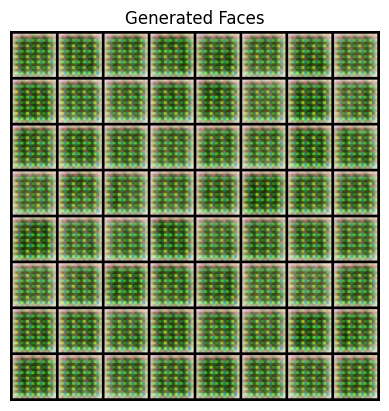

In [30]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/drive/MyDrive/GAN-Face-Generation/outputs/images/epoch_10.png")

plt.imshow(img)
plt.axis("off")
plt.title("Generated Faces")